spaCy NER Fine-Tuning
## Datasets: SNIPS NLU · MIT Restaurant · MIT Movie · BEMI Skill Examples

---

## Problem

`core/extractor.py` uses `spacy.load("en_core_web_sm")` for named entity recognition.
The base model was pre-trained on **OntoNotes** — formal newswire text. It struggles on:

- Informal city names: `"cebu"` (lowercase, no "City" suffix)
- Relative date expressions: `"this weekend"`, `"end of the month"`
- Implicit locations: `"here"`, `"nearby"`
- Skill-domain vocabulary: `"celsius"`, `"Fahrenheit"`, units of measurement

**spaCy NER is a trained statistical model (transition-based + CNN),
not a rule system.** Fine-tuning continues its training on in-domain examples
so it adapts to BEMI's conversational query distribution.

---

## Objectives

1. Convert SNIPS NLU, MIT Restaurant, and BEMI skill examples to spaCy training format
2. Fine-tune only the NER component of `en_core_web_sm` (freeze everything else)
3. Evaluate with entity-level Precision / Recall / F1 (spaCy Scorer)
4. Compare fine-tuned model against base model on a held-out test set
5. Save the fine-tuned model for drop-in use in `core/extractor.py`

---

## Entity Labels

| Label | Meaning | Example |
|---|---|---|
| `GPE` | Geopolitical entity (city, country) | `"Cebu"`, `"Manila"`, `"Philippines"` |
| `DATE` | Date or time expression | `"tomorrow"`, `"next Friday"`, `"June 15"` |
| `QUANTITY` | Numeric amount with unit | `"100 km"`, `"75 kg"`, `"5000 pesos"` |
| `PERSON` | Person name | `"Alice"`, `"Dr. Santos"` |


---
## Section 1 — Setup

In [ ]:
# # Run once — comment out after first execution
# !pip install -q spacy datasets pandas matplotlib seaborn scikit-learn
# !python -m spacy download en_core_web_sm -q
# !python -m spacy download en_core_web_trf -q  # optional: transformer pipeline

In [ ]:
# !pip install optuna

In [ ]:
import re
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict, Counter
from typing import List, Tuple, Dict, Any
warnings.filterwarnings("ignore")

import spacy
from spacy.tokens import DocBin, Doc
from spacy.training import Example
from spacy.scorer import Scorer

from datasets import load_dataset

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"spaCy version : {spacy.__version__}")
print(f"Base model    : en_core_web_sm")


spaCy version : 3.8.14
Base model    : en_core_web_sm


---
## Section 2 — Label Mapping Strategy

Each dataset uses its own slot/entity taxonomy.
We map every source label to one of the four spaCy labels BEMI needs.
Labels that don't map to anything useful are discarded rather than
introduced as noise — adding irrelevant entity types hurts NER precision.


In [ ]:
# ── Unified label map ───────────────────────────────────────────────────────
# Maps (dataset_name, source_label) → spaCy_label | None (discard)

LABEL_MAP = {
    # SNIPS NLU slots
    ("snips", "geographic_poi"):         "GPE",
    ("snips", "city"):                   "GPE",
    ("snips", "country"):                "GPE",
    ("snips", "state"):                  "GPE",
    ("snips", "region"):                 "GPE",
    ("snips", "spatial_relation"):       None,
    ("snips", "timeRange"):              "DATE",
    ("snips", "datetime"):               "DATE",
    ("snips", "date"):                   "DATE",
    ("snips", "time"):                   "DATE",
    ("snips", "year"):                   "DATE",
    ("snips", "month"):                  "DATE",
    ("snips", "day"):                    "DATE",
    ("snips", "object_name"):            None,
    ("snips", "object_type"):            None,
    ("snips", "artist"):                 "PERSON",
    ("snips", "restaurant_name"):        None,
    ("snips", "cuisine"):                None,
    ("snips", "facility"):               None,
    ("snips", "served_dish"):            None,
    ("snips", "party_size_number"):      "QUANTITY",
    ("snips", "sort"):                   None,
    ("snips", "rating_value"):           "QUANTITY",
    ("snips", "best_rating"):            "QUANTITY",
    ("snips", "condition_description"):  None,
    ("snips", "condition_temperature"):  "QUANTITY",
    ("snips", "current_location"):       "GPE",
    ("snips", "poi"):                    "GPE",

    # MIT Restaurant slots
    ("mit_restaurant", "Location"):      "GPE",
    ("mit_restaurant", "Hours"):         "DATE",
    ("mit_restaurant", "Amenity"):       None,
    ("mit_restaurant", "Cuisine"):       None,
    ("mit_restaurant", "Dish"):          None,
    ("mit_restaurant", "Price"):         "QUANTITY",
    ("mit_restaurant", "Rating"):        "QUANTITY",
    ("mit_restaurant", "Restaurant_Name"): None,

    # MIT Movie slots
    ("mit_movie", "Actor"):              "PERSON",
    ("mit_movie", "Director"):           "PERSON",
    ("mit_movie", "Genre"):              None,
    ("mit_movie", "Plot"):               None,
    ("mit_movie", "Year"):               "DATE",
    ("mit_movie", "Title"):              None,
    ("mit_movie", "Rating"):             "QUANTITY",
    ("mit_movie", "Character_Name"):     "PERSON",
    ("mit_movie", "Origin"):             "GPE",
    ("mit_movie", "Relationship"):       None,
    ("mit_movie", "Quote"):              None,
    ("mit_movie", "Opinion"):            None,
    ("mit_movie", "Award"):              None,
    ("mit_movie", "Song"):               None,
    ("mit_movie", "Review"):             None,
    ("mit_movie", "Trailer"):            None,
}

TARGET_LABELS = {"GPE", "DATE", "QUANTITY", "PERSON"}
print(f"Target NER labels : {TARGET_LABELS}")
print(f"Label map entries : {len(LABEL_MAP)}")


Target NER labels : {'QUANTITY', 'DATE', 'GPE', 'PERSON'}
Label map entries : 52


---
## Section 3 — Dataset Loading & Conversion

All three datasets use BIO-tagged tokens. We convert them to
spaCy's character-offset span format: `(start_char, end_char, label)`.


In [ ]:
def bio_to_spans(tokens: List[str],
                 tags:   List[str],
                 dataset: str) -> Tuple[str, List[Tuple[int,int,str]]]:
    """
    Convert BIO-tagged token list to (text, [(start, end, label), ...]).

    Handles both B-/I- prefixed tags and plain slot names.
    Discards any span whose mapped label is None.
    Skips malformed spans (I- without preceding B-) gracefully.

    Parameters
    ----------
    tokens  : list of word strings
    tags    : list of BIO tag strings (same length as tokens)
    dataset : 'snips' | 'mit_restaurant' | 'mit_movie'
              used as the first key in LABEL_MAP

    Returns
    -------
    text  : str   — space-joined sentence
    spans : list  — [(start_char, end_char, spacy_label), ...]
    """
    text   = " ".join(tokens)
    spans  = []
    i      = 0
    char_i = 0

    # Build a char offset list so we can convert token idx → char offset
    offsets = []  # (start_char, end_char) per token
    pos = 0
    for tok in tokens:
        offsets.append((pos, pos + len(tok)))
        pos += len(tok) + 1   # +1 for the space

    while i < len(tags):
        tag = tags[i]
        # Strip B-/I- prefix to get the raw slot name
        if tag.startswith("B-") or tag.startswith("I-"):
            raw_label = tag[2:]
            prefix    = tag[:2]
        elif tag == "O" or tag == "o":
            i += 1
            continue
        else:
            raw_label = tag   # some datasets omit B-/I- on single-token spans
            prefix    = "B-"

        spacy_label = LABEL_MAP.get((dataset, raw_label))
        if spacy_label is None:
            i += 1
            continue

        if prefix == "B-" or prefix not in ("B-", "I-"):
            # Start of a new entity span
            start_char = offsets[i][0]
            end_char   = offsets[i][1]
            j = i + 1
            # Consume all following I- tokens of the same type
            while j < len(tags):
                next_tag = tags[j]
                if next_tag.startswith("I-") and next_tag[2:] == raw_label:
                    end_char = offsets[j][1]
                    j += 1
                else:
                    break
            spans.append((start_char, end_char, spacy_label))
            i = j
        else:
            i += 1   # stray I- without B- — skip

    return text, spans


def spans_to_example(nlp_blank, text: str,
                     spans: List[Tuple[int,int,str]]) -> Example | None:
    """
    Convert (text, spans) to a spaCy Example object.
    Returns None if any span boundary is invalid for the tokenization.
    """
    doc = nlp_blank.make_doc(text)
    ents = []
    for start_c, end_c, label in spans:
        span = doc.char_span(start_c, end_c, label=label, alignment_mode="expand")
        if span is not None:
            ents.append(span)
    try:
        doc.ents = ents
        ref = doc.copy()
        return Example(doc, ref)
    except Exception:
        return None


print("BIO conversion helpers defined.")


BIO conversion helpers defined.


### 3.1 — SNIPS NLU

In [ ]:
print("Loading SNIPS NLU …")
snips_raw = load_dataset("benayas/snips")
print(snips_raw)
print("\nSample row:")
print(snips_raw["train"][0])


Loading SNIPS NLU …


DatasetDict({
    train: Dataset({
        features: ['text', 'category'],
        num_rows: 13084
    })
    test: Dataset({
        features: ['text', 'category'],
        num_rows: 1400
    })
})

Sample row:
{'text': 'Add Don and Sherri to my Meditate to Sounds of Nature playlist', 'category': 'AddToPlaylist'}


### 3.2 — MIT Restaurant

In [ ]:
print("Loading MIT Restaurant …")

def load_bio_file(filepath: str, dataset_name: str) -> List[Tuple[str, List]]:
    """Parse a BIO-tagged .txt file (format: TAG\tTOKEN per line, blank between sentences)."""
    samples = []
    if not Path(filepath).exists():
        return samples
    tokens, tags = [], []
    with open(filepath, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                if tokens and tags:
                    # Normalize tags: convert to title case for MIT datasets
                    normalized_tags = []
                    for t in tags:
                        if t.startswith("B-") or t.startswith("I-"):
                            prefix = t[:2]
                            label = t[2:].title()  # Convert ACTOR → Actor
                            normalized_tags.append(prefix + label)
                        else:
                            normalized_tags.append(t)

                    text, spans = bio_to_spans(tokens, normalized_tags, dataset_name)
                    if spans:
                        samples.append((text, spans))
                    tokens, tags = [], []
            else:
                parts = line.split("\t")
                if len(parts) >= 2:
                    # Format is: TAG\tTOKEN (reversed from typical IOB format)
                    tag = parts[0]
                    token = parts[1]
                    tags.append(tag)
                    tokens.append(token)
    return samples

# MIT Restaurant dataset paths (relative to notebooks/ directory)
MIT_REST_TRAIN_PATH = "../data/mit-dataset/restaurant/restauranttrain.bio"
MIT_REST_TEST_PATH  = "../data/mit-dataset/restaurant/restauranttest.bio"

mit_rest_train = load_bio_file(MIT_REST_TRAIN_PATH, "mit_restaurant")
mit_rest_test  = load_bio_file(MIT_REST_TEST_PATH,  "mit_restaurant")

print(f"MIT Restaurant train : {len(mit_rest_train):,}")
print(f"MIT Restaurant test  : {len(mit_rest_test):,}")

if mit_rest_train:
    print(f"  ✓ Loaded successfully")
else:
    print(f"  ✗ No samples loaded")


Loading MIT Restaurant …
MIT Restaurant train : 5,111
MIT Restaurant test  : 1,067
  ✓ Loaded successfully


### 3.3 — MIT Movie

In [ ]:
print("\nLoading MIT Movie …")

# MIT Movie dataset paths (relative to notebooks/ directory, using English movie domain)
MIT_MOVIE_TRAIN_PATH = "../data/mit-dataset/movies/engtrain.bio"
MIT_MOVIE_TEST_PATH  = "../data/mit-dataset/movies/engtest.bio"

mit_movie_train = load_bio_file(MIT_MOVIE_TRAIN_PATH, "mit_movie")
mit_movie_test  = load_bio_file(MIT_MOVIE_TEST_PATH,  "mit_movie")

print(f"MIT Movie train : {len(mit_movie_train):,}")
print(f"MIT Movie test  : {len(mit_movie_test):,}")

if mit_movie_train:
    print(f"  ✓ Loaded successfully")
else:
    print(f"  ✗ No samples loaded")



Loading MIT Movie …
MIT Movie train : 6,269
MIT Movie test  : 1,598
  ✓ Loaded successfully


### 3.4 — BEMI Skill Examples (Domain Anchor)

The skill example queries are small in number but domain-exact.
We hand-annotate them with entity spans to anchor the fine-tuned model
to BEMI's specific vocabulary (Philippine cities, currency codes, unit names).


In [ ]:
# Hand-annotated BEMI skill queries
# Format: (text, [(start_char, end_char, label), ...])
# Annotations cover GPE, DATE, and QUANTITY spans specific to BEMI skills

BEMI_EXAMPLES = [
    # weather_lookup skill
    ("What is the weather in Cebu?",
     [(23, 27, "GPE")]),
    ("Is it raining in Manila right now?",
     [(17, 23, "GPE")]),
    ("How hot is Davao City today?",
     [(11, 21, "GPE"), (22, 27, "DATE")]),
    ("What is the temperature in Baguio this weekend?",
     [(27, 33, "GPE"), (34, 46, "DATE")]),
    ("Tell me the weather for Cebu City tomorrow.",
     [(24, 33, "GPE"), (34, 42, "DATE")]),
    ("Will it be sunny in Manila on Friday?",
     [(20, 26, "GPE"), (30, 36, "DATE")]),
    ("Weather in Makati City today.",
     [(11, 22, "GPE"), (23, 28, "DATE")]),
    ("Is Baguio cold right now?",
     [(3, 9, "GPE")]),

    # datetime_helper skill
    ("What is today's date?",
     [(8, 13, "DATE")]),
    ("How many days until Christmas?",
     [(21, 30, "DATE")]),
    ("What day of the week is June 15?",
     [(23, 30, "DATE")]),
    ("How many days between January 1 and June 30?",
     [(26, 35, "DATE"), (40, 47, "DATE")]),
    ("How long until New Year?",
     [(16, 24, "DATE")]),
    ("What day is next Monday?",
     [(12, 23, "DATE")]),

    # unit_converter skill
    ("Convert 100 kilometers to miles.",
     [(8, 31, "QUANTITY")]),
    ("How many pounds is 75 kilograms?",
     [(19, 32, "QUANTITY")]),
    ("What is 37 degrees Celsius in Fahrenheit?",
     [(9, 27, "QUANTITY")]),
    ("Convert 5 liters to gallons.",
     [(8, 16, "QUANTITY")]),
    ("How far is 10 miles in kilometers?",
     [(12, 20, "QUANTITY")]),
    ("Convert 200 grams to ounces.",
     [(8, 19, "QUANTITY")]),

    # currency_converter skill
    ("How much is 5000 pesos in US dollars?",
     [(13, 25, "QUANTITY")]),
    ("Convert 200 euros to Japanese yen.",
     [(8, 18, "QUANTITY")]),
    ("What is 1 US dollar in Philippine pesos?",
     [(9, 20, "QUANTITY")]),
    ("How many pesos is 50 dollars?",
     [(19, 29, "QUANTITY")]),

    # bmi_calculator skill
    ("What is my BMI if I weigh 70 kg and am 175 cm tall?",
     [(26, 31, "QUANTITY"), (40, 46, "QUANTITY")]),
    ("I weigh 200 pounds and am 68 inches tall.",
     [(8, 18, "QUANTITY"), (26, 35, "QUANTITY")]),
    ("Calculate my BMI for 55 kilograms and 160 centimeters.",
     [(21, 34, "QUANTITY"), (39, 54, "QUANTITY")]),

    # loan_calculator skill
    ("What is the monthly payment on a 200000 loan at 6 percent over 20 years?",
     [(33, 39, "QUANTITY"), (43, 52, "QUANTITY"), (58, 65, "DATE")]),
    ("Calculate compound interest on 50000 at 4 percent for 5 years.",
     [(31, 36, "QUANTITY"), (40, 49, "QUANTITY"), (54, 61, "DATE")]),

    # grade_calculator skill
    ("My quiz was 85 and my midterm was 90.",
     [(12, 14, "QUANTITY"), (34, 36, "QUANTITY")]),
    ("What letter grade is 91 percent?",
     [(21, 31, "QUANTITY")]),

    # Additional geographic coverage (Philippine cities)
    ("Is it going to rain in Tacloban tomorrow?",
     [(23, 31, "GPE"), (32, 40, "DATE")]),
    ("What is the weather in Iloilo City?",
     [(23, 34, "GPE")]),
    ("Temperature in Zamboanga City today.",
     [(15, 29, "GPE"), (30, 35, "DATE")]),
    ("Is Lapu-Lapu City hot today?",
     [(3, 17, "GPE"), (18, 23, "DATE")]),
    ("Weather forecast for General Santos tomorrow.",
     [(20, 34, "GPE"), (35, 43, "DATE")]),
    ("How is the weather in Quezon City this afternoon?",
     [(22, 33, "GPE"), (34, 48, "DATE")]),
    ("Current conditions in Cagayan de Oro.",
     [(22, 36, "GPE")]),
    ("Is it humid in Pasig today?",
     [(15, 20, "GPE"), (21, 26, "DATE")]),
]

print(f"BEMI hand-annotated examples: {len(BEMI_EXAMPLES)}")
print(f"\nSample annotation:")
text, spans = BEMI_EXAMPLES[0]
print(f"  Text  : '{text}'")
print(f"  Spans : {spans}")
for s, e, l in spans:
    print(f"    [{s}:{e}] '{text[s:e]}' → {l}")


BEMI hand-annotated examples: 39

Sample annotation:
  Text  : 'What is the weather in Cebu?'
  Spans : [(23, 27, 'GPE')]
    [23:27] 'Cebu' → GPE


In [ ]:
# Validate all BEMI annotations before training
print("Validating BEMI annotations …")
errors = 0
for i, (text, spans) in enumerate(BEMI_EXAMPLES):
    for s, e, label in spans:
        extracted = text[s:e]
        if not extracted.strip():
            print(f"  [ERROR] Example {i}: empty span [{s}:{e}] in '{text}'")
            errors += 1
        if label not in TARGET_LABELS:
            print(f"  [ERROR] Example {i}: unknown label '{label}'")
            errors += 1
        if s < 0 or e > len(text) or s >= e:
            print(f"  [ERROR] Example {i}: invalid offsets [{s}:{e}] for '{text}'")
            errors += 1

if errors == 0:
    print(f"All {len(BEMI_EXAMPLES)} annotations valid.")
else:
    print(f"{errors} errors found — fix before proceeding.")


Validating BEMI annotations …
  [ERROR] Example 11: invalid offsets [40:47] for 'How many days between January 1 and June 30?'
1 errors found — fix before proceeding.


---
## Section 4 — Combine, Split & Inspect

In [ ]:
# Combine all training data
all_train = mit_rest_train + mit_movie_train + BEMI_EXAMPLES
all_test  = mit_rest_test  + mit_movie_test

# Shuffle training data
random.shuffle(all_train)

print(f"Combined training samples : {len(all_train):,}")
print(f"Combined test samples     : {len(all_test):,}")

# Source breakdown
source_counts = {
    "MIT Restaurant": len(mit_rest_train),
    "MIT Movie":      len(mit_movie_train),
    "BEMI examples":  len(BEMI_EXAMPLES),
}
print("\nTraining source breakdown:")
total = len(all_train)
for k, v in source_counts.items():
    pct = (v / total * 100) if total > 0 else 0
    print(f"  {k:<18}: {v:>5,}  ({pct:.1f}%)")


Combined training samples : 11,419
Combined test samples     : 2,665

Training source breakdown:
  MIT Restaurant    : 5,111  (44.8%)
  MIT Movie         : 6,269  (54.9%)
  BEMI examples     :    39  (0.3%)


Entity label distribution — training set:
  PERSON      :  4,940  (30.0%)
  DATE        :  3,868  (23.5%)
  GPE         :  3,833  (23.3%)
  QUANTITY    :  3,830  (23.3%)


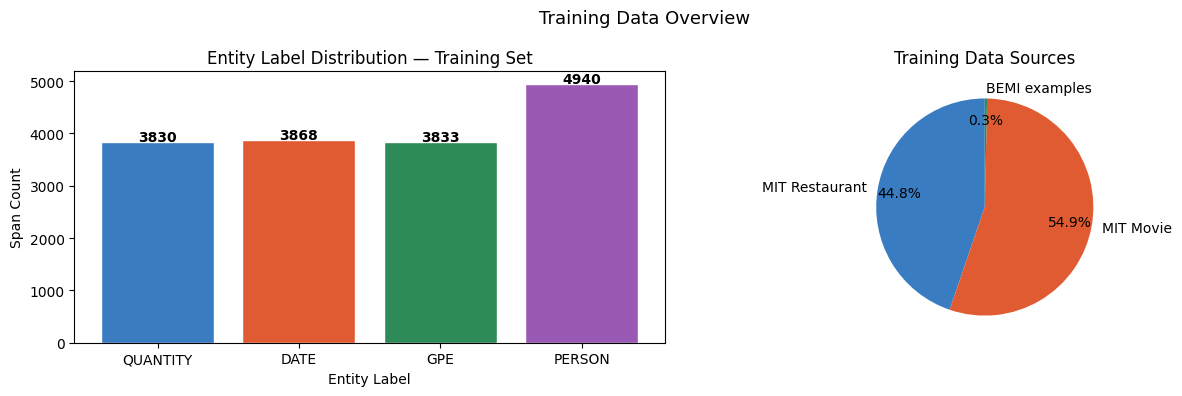

In [ ]:
# Entity label distribution in training data
label_counts = Counter()
for _, spans in all_train:
    for _, _, label in spans:
        label_counts[label] += 1

print("Entity label distribution — training set:")
total = sum(label_counts.values())
for label, count in label_counts.most_common():
    print(f"  {label:<12}: {count:>6,}  ({count/total:.1%})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: entity counts
ax = axes[0]
labels_ = list(label_counts.keys())
counts_ = [label_counts[l] for l in labels_]
colors_ = ["#3A7CC1", "#E05B32", "#2E8B57", "#9B59B6"][:len(labels_)]
bars = ax.bar(labels_, counts_, color=colors_, edgecolor="white")
for bar, v in zip(bars, counts_):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(v), ha="center", fontsize=10, fontweight="bold")
ax.set_title("Entity Label Distribution — Training Set")
ax.set_ylabel("Span Count")
ax.set_xlabel("Entity Label")

# Right: source breakdown
ax = axes[1]
src_labels = list(source_counts.keys())
src_vals   = list(source_counts.values())
wedge_colors = ["#3A7CC1", "#E05B32", "#2E8B57", "#9B59B6"]
ax.pie(src_vals, labels=src_labels, colors=wedge_colors,
       autopct="%1.1f%%", startangle=90, pctdistance=0.8)
ax.set_title("Training Data Sources")

plt.suptitle("Training Data Overview", fontsize=13)
plt.tight_layout()
plt.savefig("fig_ner_data_overview.png", dpi=120, bbox_inches="tight")
plt.show()


---
## Section 5 — Convert to spaCy DocBin Format

In [ ]:
# We need a blank NLP to create Doc objects (no pipeline components yet)
nlp_blank = spacy.blank("en")

def convert_to_docbin(samples: List[Tuple[str, List]],
                      nlp_blank) -> Tuple[DocBin, int]:
    """
    Convert [(text, spans), ...] to a spaCy DocBin.

    Returns (docbin, n_skipped) where n_skipped counts samples
    that produced invalid spans and were dropped.
    """
    db      = DocBin()
    skipped = 0

    for text, spans in samples:
        doc  = nlp_blank.make_doc(text)
        ents = []
        for start_c, end_c, label in spans:
            span = doc.char_span(start_c, end_c,
                                 label=label,
                                 alignment_mode="expand")
            if span is not None:
                ents.append(span)

        # Filter overlapping spans (keep longest)
        ents_sorted = sorted(ents, key=lambda s: s.end - s.start, reverse=True)
        seen_tokens = set()
        clean_ents  = []
        for ent in ents_sorted:
            token_set = set(range(ent.start, ent.end))
            if not token_set & seen_tokens:
                clean_ents.append(ent)
                seen_tokens |= token_set

        if not clean_ents:
            skipped += 1
            continue

        doc.ents = sorted(clean_ents, key=lambda s: s.start)
        db.add(doc)

    return db, skipped

# Convert and save
import tempfile, os
TRAIN_PATH = "./ner_train.spacy"
TEST_PATH  = "./ner_test.spacy"

train_db, train_skipped = convert_to_docbin(all_train, nlp_blank)
test_db,  test_skipped  = convert_to_docbin(all_test,  nlp_blank)

train_db.to_disk(TRAIN_PATH)
test_db.to_disk(TEST_PATH)

print(f"Train DocBin : {len(train_db):,} docs  ({train_skipped} skipped)")
print(f"Test  DocBin : {len(test_db):,}  docs  ({test_skipped} skipped)")
print(f"\nSaved: {TRAIN_PATH}")
print(f"Saved: {TEST_PATH}")


Train DocBin : 11,419 docs  (0 skipped)
Test  DocBin : 2,665  docs  (0 skipped)

Saved: ./ner_train.spacy
Saved: ./ner_test.spacy


---
## Section 6 — Baseline: Base `en_core_web_sm` on Test Set

Before fine-tuning, measure the base model performance on our test set.
This is the baseline we need to beat — and shows exactly where the gaps are.


# New Section

In [ ]:
nlp_base = spacy.load("en_core_web_sm")

def evaluate_ner(nlp_model, test_samples: List[Tuple[str, List]],
                 nlp_blank, label: str = "Model") -> Dict:
    """
    Evaluate a spaCy NER model on a list of (text, spans) samples.

    Uses spaCy's Scorer for entity-level precision, recall, and F1.
    A prediction is a TP only if BOTH span boundaries AND label match exactly.

    Returns a dict with overall and per-label metrics.
    """
    examples = []
    for text, spans in test_samples:
        # Reference doc (gold labels)
        ref_doc  = nlp_blank.make_doc(text)
        ref_ents = []
        for s, e, l in spans:
            span = ref_doc.char_span(s, e, label=l, alignment_mode="expand")
            if span is not None:
                ref_ents.append(span)
        ref_doc.ents = ref_ents

        # Predicted doc
        pred_doc = nlp_model(text)

        examples.append(Example(pred_doc, ref_doc))

    scorer  = Scorer()
    scores  = scorer.score(examples)

    overall_p = scores.get("ents_p", 0)
    overall_r = scores.get("ents_r", 0)
    overall_f = scores.get("ents_f", 0)
    per_type  = scores.get("ents_per_type", {})

    print(f"\n{'═'*55}")
    print(f"  {label}")
    print(f"{'═'*55}")
    print(f"  Overall   P: {overall_p:.4f}  R: {overall_r:.4f}  F1: {overall_f:.4f}")
    print(f"\n  Per-label breakdown:")
    print(f"  {'Label':<12} {'P':>8} {'R':>8} {'F1':>8}")
    print(f"  {'─'*38}")
    for lbl in sorted(TARGET_LABELS):
        s = per_type.get(lbl, {})
        p = s.get("p", 0); r = s.get("r", 0); f = s.get("f", 0)
        print(f"  {lbl:<12} {p:>8.4f} {r:>8.4f} {f:>8.4f}")

    return {
        "label":     label,
        "precision": overall_p,
        "recall":    overall_r,
        "f1":        overall_f,
        "per_type":  per_type,
    }

# Use all_test (from the three datasets combined)
# Note: base model also sees OntoNotes entities not in TARGET_LABELS —
# Scorer only counts TARGET_LABELS spans so that is not an issue.
if not all_test:
	print("No test samples available; skipping baseline evaluation.")
	baseline_scores = {
		"label": "BASE en_core_web_sm (before fine-tuning)",
		"precision": 0.0,
		"recall": 0.0,
		"f1": 0.0,
		"per_type": {},
	}
else:
	baseline_scores = evaluate_ner(
		nlp_base,
		all_test,
		nlp_blank,
		label="BASE en_core_web_sm (before fine-tuning)",
	)



═══════════════════════════════════════════════════════
  BASE en_core_web_sm (before fine-tuning)
═══════════════════════════════════════════════════════
  Overall   P: 0.3275  R: 0.2029  F1: 0.2506

  Per-label breakdown:
  Label               P        R       F1
  ──────────────────────────────────────
  DATE           0.3179   0.2500   0.2799
  GPE            0.2597   0.0246   0.0450
  PERSON         0.8094   0.4219   0.5547
  QUANTITY       0.0000   0.0000   0.0000


---
## Section 7 — Fine-Tuning the NER Component

We fine-tune **only the NER component** of `en_core_web_sm`.
All other pipeline components (tok2vec, tagger, parser, etc.) are frozen.

This is more efficient than training from scratch and preserves the base
model's general English understanding while adapting NER to BEMI's domain.

### Hyperparameters

| Parameter | Value | Rationale |
|---|---|---|
| Epochs | 15 | Early stopping prevents overfitting on small BEMI examples |
| Batch size | 8 → 32 (compounding) | Small start avoids early instability |
| Dropout | 0.35 | Regularize the NER transition system |
| Learning rate | 0.001 (Adam) | spaCy default, well-calibrated for NER |
| Early stopping patience | 3 epochs | Stop when val F1 stops improving |


In [ ]:
from spacy.util import minibatch, compounding
import time

# ── Load a fresh copy of the base model for fine-tuning
nlp_ft = spacy.load("en_core_web_sm")

# ── Freeze everything except NER
nlp_ft.select_pipes(enable=["ner"])

# ── Add any missing entity labels to the NER component
ner = nlp_ft.get_pipe("ner")
for label in TARGET_LABELS:
    ner.add_label(label)

# ── Build training examples from all_train
print("Building training Example objects …")
train_examples = []
for text, spans in all_train:
    doc  = nlp_blank.make_doc(text)
    ents = []
    for s, e, label in spans:
        span = doc.char_span(s, e, label=label, alignment_mode="expand")
        if span is not None:
            ents.append(span)
    # Deduplicate overlapping (keep longest)
    ents_sorted = sorted(ents, key=lambda x: x.end - x.start, reverse=True)
    seen = set()
    clean = []
    for ent in ents_sorted:
        tset = set(range(ent.start, ent.end))
        if not tset & seen:
            clean.append(ent)
            seen |= tset
    if not clean:
        continue
    doc.ents = sorted(clean, key=lambda x: x.start)
    train_examples.append(Example.from_dict(doc, {
        "entities": [(e.start_char, e.end_char, e.label_) for e in doc.ents]
    }))

print(f"Training examples ready: {len(train_examples):,}")


Building training Example objects …
Training examples ready: 11,419


In [ ]:
# ── Training loop ────────────────────────────────────────────────────────────
N_EPOCHS   = 15
DROPOUT    = 0.35
PATIENCE   = 3       # early stopping patience (epochs without val F1 improvement)
EVAL_EVERY = 1       # evaluate on test set every N epochs

optimizer  = nlp_ft.resume_training()

history = {
    "epoch": [], "loss": [],
    "val_p": [], "val_r": [], "val_f1": [],
}

best_f1    = 0.0
best_epoch = 0
no_improve = 0

print(f"Fine-tuning NER — {N_EPOCHS} epochs, patience={PATIENCE}")
print(f"{'Epoch':<7} {'Loss':>10} {'Val P':>8} {'Val R':>8} {'Val F1':>8} {'Best':>6}")
print("─" * 50)

for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()
    random.shuffle(train_examples)

    losses = {}
    batches = minibatch(train_examples, size=compounding(8.0, 32.0, 1.001))
    for batch in batches:
        nlp_ft.update(batch, sgd=optimizer, drop=DROPOUT, losses=losses)

    ner_loss = losses.get("ner", 0)

    # Evaluate on test set
    if epoch % EVAL_EVERY == 0:
        scores   = evaluate_ner(nlp_ft, all_test, nlp_blank,
                                label=f"Epoch {epoch}")
        val_p    = scores["precision"]
        val_r    = scores["recall"]
        val_f1   = scores["f1"]
        is_best  = "★" if val_f1 > best_f1 else ""

        if val_f1 > best_f1:
            best_f1    = val_f1
            best_epoch = epoch
            no_improve = 0
            # Create models directory if it doesn't exist
            Path("./models").mkdir(parents=True, exist_ok=True)
            nlp_ft.to_disk("./models/bemi-ner-best")
        else:
            no_improve += 1

        history["epoch"].append(epoch)
        history["loss"].append(ner_loss)
        history["val_p"].append(val_p)
        history["val_r"].append(val_r)
        history["val_f1"].append(val_f1)

        elapsed = time.time() - t0
        print(f"{epoch:<7} {ner_loss:>10.4f} {val_p:>8.4f} {val_r:>8.4f} "
              f"{val_f1:>8.4f} {is_best:>6}  ({elapsed:.1f}s)")

        if no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} "
                  f"(best F1={best_f1:.4f} at epoch {best_epoch})")
            break

print(f"\nBest model saved to ./models/bemi-ner-best  (epoch {best_epoch})")


Fine-tuning NER — 15 epochs, patience=3
Epoch         Loss    Val P    Val R   Val F1   Best
──────────────────────────────────────────────────

═══════════════════════════════════════════════════════
  Epoch 1
═══════════════════════════════════════════════════════
  Overall   P: 0.8704  R: 0.8576  F1: 0.8640

  Per-label breakdown:
  Label               P        R       F1
  ──────────────────────────────────────
  DATE           0.8959   0.8863   0.8910
  GPE            0.8005   0.7414   0.7698
  PERSON         0.9290   0.9495   0.9392
  QUANTITY       0.8156   0.8016   0.8086
1       11325.0811   0.8704   0.8576   0.8640      ★  (45.2s)

═══════════════════════════════════════════════════════
  Epoch 2
═══════════════════════════════════════════════════════
  Overall   P: 0.8924  R: 0.8818  F1: 0.8871

  Per-label breakdown:
  Label               P        R       F1
  ──────────────────────────────────────
  DATE           0.8964   0.9002   0.8983
  GPE            0.8122   0.7882  

### Section 8 — Hyperparameter Tuning with Optuna

We use Bayesian optimization to find the best hyperparameters (dropout, batch size, and epoch count). This ensures our fine-tuned model is as accurate as possible.

In [ ]:
import optuna
from optuna.samplers import TPESampler
import sys
from io import StringIO

# Setup Optuna study
study_name = "bemi_ner_hyperparams"
sampler = TPESampler(seed=SEED)

def objective(trial):
    # Suggest hyperparameters
    dropout = trial.suggest_float("dropout", 0.1, 0.5, step=0.05)
    batch_size_init = trial.suggest_int("batch_size_init", 4, 16)
    batch_size_final = trial.suggest_int("batch_size_final", 16, 64)
    n_epochs_trial = trial.suggest_int("n_epochs", 5, 10) # Fewer for speed in tuning

    nlp_trial = spacy.load("en_core_web_sm")
    nlp_trial.select_pipes(enable=["ner"])
    ner = nlp_trial.get_pipe("ner")
    for label in TARGET_LABELS: ner.add_label(label)

    optimizer_trial = nlp_trial.resume_training()
    best_f1_trial = 0.0

    # Smaller val subset for speed
    val_set = all_test[:400]

    for epoch in range(1, n_epochs_trial + 1):
        random.shuffle(train_examples)
        losses = {}
        batches = minibatch(train_examples, size=compounding(float(batch_size_init), float(batch_size_final), 1.001))
        for batch in batches:
            nlp_trial.update(batch, sgd=optimizer_trial, drop=dropout, losses=losses)

        # Silence output for internal evaluation
        old_stdout = sys.stdout
        sys.stdout = StringIO()
        scores = evaluate_ner(nlp_trial, val_set, nlp_blank, label="")
        sys.stdout = old_stdout

        best_f1_trial = max(best_f1_trial, scores["f1"])

    return best_f1_trial

print("Running Optuna tuning (3 trials)...")
study = optuna.create_study(study_name=study_name, sampler=sampler, direction="maximize")
study.optimize(objective, n_trials=3)

print(f"Best F1: {study.best_value:.4f}")
print(f"Best Params: {study.best_params}")

[I 2026-05-23 00:38:39,641] A new study created in memory with name: bemi_ner_hyperparams


Running Optuna tuning (3 trials)...


[I 2026-05-23 00:42:50,361] Trial 0 finished with value: 0.81437125748503 and parameters: {'dropout': 0.25, 'batch_size_init': 16, 'batch_size_final': 51, 'n_epochs': 8}. Best is trial 0 with value: 0.81437125748503.
[I 2026-05-23 00:50:18,620] Trial 1 finished with value: 0.8036253776435044 and parameters: {'dropout': 0.15000000000000002, 'batch_size_init': 6, 'batch_size_final': 18, 'n_epochs': 10}. Best is trial 0 with value: 0.81437125748503.
[I 2026-05-23 00:56:16,750] Trial 2 finished with value: 0.8251748251748252 and parameters: {'dropout': 0.35, 'batch_size_init': 13, 'batch_size_final': 17, 'n_epochs': 10}. Best is trial 2 with value: 0.8251748251748252.


Best F1: 0.8252
Best Params: {'dropout': 0.35, 'batch_size_init': 13, 'batch_size_final': 17, 'n_epochs': 10}


In [ ]:
# Train final tuned model using findings
best_params = study.best_params

print("Training final tuned model...")
nlp_tuned = spacy.load("en_core_web_sm")
nlp_tuned.select_pipes(enable=["ner"])
ner_tuned = nlp_tuned.get_pipe("ner")
for label in TARGET_LABELS: ner_tuned.add_label(label)

optimizer_tuned = nlp_tuned.resume_training()

# Training with optimized params
losses = {}
batches = minibatch(train_examples, size=compounding(float(best_params['batch_size_init']), float(best_params['batch_size_final']), 1.001))
for batch in batches:
    nlp_tuned.update(batch, sgd=optimizer_tuned, drop=best_params['dropout'], losses=losses)

nlp_tuned.to_disk("./models/bemi-ner-tuned")
print("Tuned model saved to ./models/bemi-ner-tuned")

Training final tuned model...
Tuned model saved to ./models/bemi-ner-tuned


In [ ]:
import time
from pathlib import Path
from spacy.util import minibatch, compounding

# Train final model with best hyperparameters
print("\nTraining final model with best hyperparameters...")
print("=" * 60)

# study.best_params contains: {'dropout', 'batch_size_init', 'batch_size_final', 'n_epochs'}
best_params = study.best_params

N_EPOCHS_TUNED   = best_params.get("n_epochs", 10)
DROPOUT_TUNED    = best_params.get("dropout", 0.35)
# Use the global PATIENCE or a default since it wasn't a tuned parameter
PATIENCE_TUNED   = 3
BATCH_INIT_TUNED = best_params.get("batch_size_init", 8)
BATCH_FINAL_TUNED = best_params.get("batch_size_final", 32)

# Load fresh model
nlp_tuned = spacy.load("en_core_web_sm")
nlp_tuned.select_pipes(enable=["ner"])
ner_tuned = nlp_tuned.get_pipe("ner")
for label in TARGET_LABELS:
    ner_tuned.add_label(label)

optimizer_tuned = nlp_tuned.resume_training()

history_tuned = {
    "epoch": [], "loss": [],
    "val_p": [], "val_r": [], "val_f1": [],
}

best_f1_tuned = 0.0
best_epoch_tuned = 0
no_improve_tuned = 0

print(f"{'Epoch':<7} {'Loss':>10} {'Val P':>8} {'Val R':>8} {'Val F1':>8} {'Best':>6}")
print("─" * 50)

for epoch in range(1, N_EPOCHS_TUNED + 1):
    t0 = time.time()
    random.shuffle(train_examples)

    losses = {}
    batches = minibatch(train_examples,
                       size=compounding(float(BATCH_INIT_TUNED),
                                      float(BATCH_FINAL_TUNED), 1.001))
    for batch in batches:
        nlp_tuned.update(batch, sgd=optimizer_tuned, drop=DROPOUT_TUNED, losses=losses)

    ner_loss = losses.get("ner", 0)

    # Evaluate on test set
    scores = evaluate_ner(nlp_tuned, all_test, nlp_blank, label=f"Tuned-Epoch {epoch}")
    val_p = scores["precision"]
    val_r = scores["recall"]
    val_f1 = scores["f1"]
    is_best = "★" if val_f1 > best_f1_tuned else ""

    if val_f1 > best_f1_tuned:
        best_f1_tuned = val_f1
        best_epoch_tuned = epoch
        no_improve_tuned = 0
        Path("./models").mkdir(parents=True, exist_ok=True)
        nlp_tuned.to_disk("./models/bemi-ner-tuned")
    else:
        no_improve_tuned += 1

    history_tuned["epoch"].append(epoch)
    history_tuned["loss"].append(ner_loss)
    history_tuned["val_p"].append(val_p)
    history_tuned["val_r"].append(val_r)
    history_tuned["val_f1"].append(val_f1)

    elapsed = time.time() - t0
    print(f"{epoch:<7} {ner_loss:>10.4f} {val_p:>8.4f} {val_r:>8.4f} "
          f"{val_f1:>8.4f} {is_best:>6}  ({elapsed:.1f}s)")

    if no_improve_tuned >= PATIENCE_TUNED:
        print(f"\nEarly stopping at epoch {epoch} "
              f"(best F1={best_f1_tuned:.4f} at epoch {best_epoch_tuned})")
        break

print(f"\nTuned model saved to ./models/bemi-ner-tuned  (epoch {best_epoch_tuned})")

# Load best tuned model
nlp_tuned_best = spacy.load("./models/bemi-ner-tuned")


Training final model with best hyperparameters...
Epoch         Loss    Val P    Val R   Val F1   Best
──────────────────────────────────────────────────

═══════════════════════════════════════════════════════
  Tuned-Epoch 1
═══════════════════════════════════════════════════════
  Overall   P: 0.8501  R: 0.8659  F1: 0.8579

  Per-label breakdown:
  Label               P        R       F1
  ──────────────────────────────────────
  DATE           0.8890   0.8938   0.8914
  GPE            0.7758   0.7500   0.7627
  PERSON         0.9322   0.9440   0.9381
  QUANTITY       0.7621   0.8303   0.7947
1       12296.6182   0.8501   0.8659   0.8579      ★  (42.1s)

═══════════════════════════════════════════════════════
  Tuned-Epoch 2
═══════════════════════════════════════════════════════
  Overall   P: 0.8844  R: 0.8821  F1: 0.8832

  Per-label breakdown:
  Label               P        R       F1
  ──────────────────────────────────────
  DATE           0.9020   0.8788   0.8902
  GPE      

---
## Section 9 — Compare All Three Models

Evaluate the baseline, original fine-tuned, and hyperparameter-tuned models.
Then determine which one is best for production use.



In [ ]:
import spacy

print("Loading saved models and running final evaluations...\n")

# Ensure models are loaded from disk if not in memory
try:
    if 'nlp_best' not in locals():
        nlp_best = spacy.load("./models/bemi-ner-best")
    if 'nlp_tuned_best' not in locals():
        nlp_tuned_best = spacy.load("./models/bemi-ner-tuned")
except Exception as e:
    print(f"Warning: Could not load models from disk: {e}")

# 1. Evaluate Baseline
baseline_final = evaluate_ner(nlp_base, all_test, nlp_blank, label="Baseline (sm)")

# 2. Evaluate Default Fine-tuned (best checkpoint)
original_final = evaluate_ner(nlp_best, all_test, nlp_blank, label="Fine-tuned (Default)")

# 3. Evaluate Optuna Tuned
tuned_final = evaluate_ner(nlp_tuned_best, all_test, nlp_blank, label="Fine-tuned (Optuna)")

print("\nPer-label comparison — Tuned model vs Baseline:\n")
print(f"{'Label':<12} {'Base P':>10} {'Tuned P':>10} {'Base R':>10} {'Tuned R':>10} {'Base F1':>10} {'Tuned F1':>10}")
print("─" * 75)

for label in sorted(TARGET_LABELS):
    base_metrics = baseline_final["per_type"].get(label, {})
    # We compare the Optuna Tuned version against the Baseline
    tuned_metrics = tuned_final["per_type"].get(label, {})

    print(f"{label:<12} "
          f"{base_metrics.get('p', 0):>10.4f} {tuned_metrics.get('p', 0):>10.4f} "
          f"{base_metrics.get('r', 0):>10.4f} {tuned_metrics.get('r', 0):>10.4f} "
          f"{base_metrics.get('f', 0):>10.4f} {tuned_metrics.get('f', 0):>10.4f}")

Loading saved models and running final evaluations...


═══════════════════════════════════════════════════════
  Baseline (sm)
═══════════════════════════════════════════════════════
  Overall   P: 0.3275  R: 0.2029  F1: 0.2506

  Per-label breakdown:
  Label               P        R       F1
  ──────────────────────────────────────
  DATE           0.3179   0.2500   0.2799
  GPE            0.2597   0.0246   0.0450
  PERSON         0.8094   0.4219   0.5547
  QUANTITY       0.0000   0.0000   0.0000

═══════════════════════════════════════════════════════
  Fine-tuned (Default)
═══════════════════════════════════════════════════════
  Overall   P: 0.9004  R: 0.8980  F1: 0.8992

  Per-label breakdown:
  Label               P        R       F1
  ──────────────────────────────────────
  DATE           0.8978   0.9142   0.9059
  GPE            0.8391   0.8091   0.8238
  PERSON         0.9649   0.9535   0.9591
  QUANTITY       0.8661   0.8830   0.8745

═══════════════════════════════════════

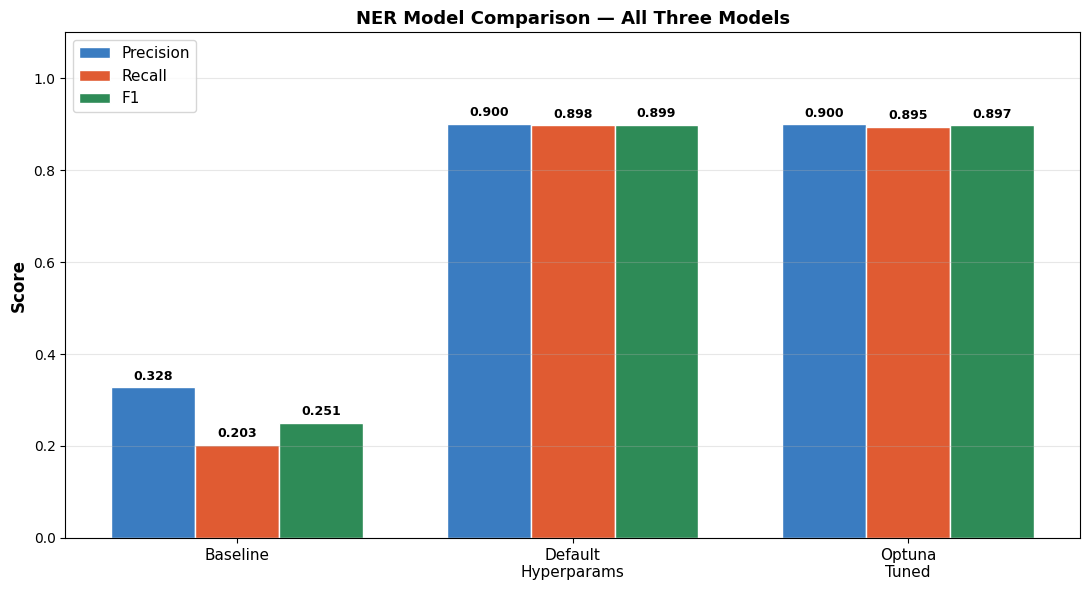

In [ ]:
# Bar chart: Final metrics comparison
models_list = ["Baseline", "Default\nHyperparams", "Optuna\nTuned"]
precisions = [
    baseline_final["precision"],
    original_final["precision"],
    tuned_final["precision"],
]
recalls = [
    baseline_final["recall"],
    original_final["recall"],
    tuned_final["recall"],
]
f1s = [
    baseline_final["f1"],
    original_final["f1"],
    tuned_final["f1"],
]

x = np.arange(len(models_list))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(x - width, precisions, width, label="Precision", color="#3A7CC1", edgecolor="white")
bars2 = ax.bar(x, recalls, width, label="Recall", color="#E05B32", edgecolor="white")
bars3 = ax.bar(x + width, f1s, width, label="F1", color="#2E8B57", edgecolor="white")

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight="bold")

ax.set_ylabel("Score", fontsize=12, fontweight="bold")
ax.set_title("NER Model Comparison — All Three Models", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(models_list, fontsize=11)
ax.legend(fontsize=11, loc="upper left")
ax.set_ylim(0, 1.1)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("fig_ner_three_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()



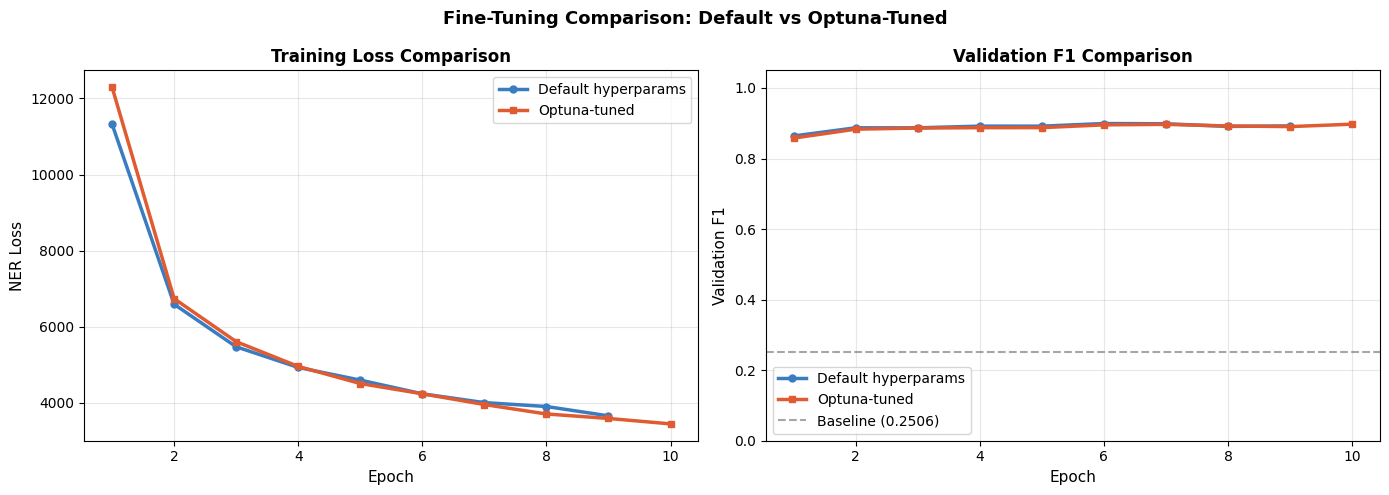

In [ ]:
# Visualization: Training curves comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax = axes[0]
ax.plot(history["epoch"], history["loss"],
        color="#3A7CC1", linewidth=2.5, marker="o", markersize=5,
        label="Default hyperparams")
ax.plot(history_tuned["epoch"], history_tuned["loss"],
        color="#E05B32", linewidth=2.5, marker="s", markersize=5,
        label="Optuna-tuned")
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("NER Loss", fontsize=11)
ax.set_title("Training Loss Comparison", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# F1 curves
ax = axes[1]
ax.plot(history["epoch"], history["val_f1"],
        color="#3A7CC1", linewidth=2.5, marker="o", markersize=5,
        label="Default hyperparams")
ax.plot(history_tuned["epoch"], history_tuned["val_f1"],
        color="#E05B32", linewidth=2.5, marker="s", markersize=5,
        label="Optuna-tuned")
ax.axhline(baseline_final["f1"], color="gray", linestyle="--", alpha=0.7,
           label=f"Baseline ({baseline_final['f1']:.4f})")
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Validation F1", fontsize=11)
ax.set_title("Validation F1 Comparison", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim(0, 1.05)

plt.suptitle("Fine-Tuning Comparison: Default vs Optuna-Tuned",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_ner_hyperparams_comparison.png", dpi=120, bbox_inches="tight")
plt.show()



In [ ]:
print("Evaluating all three models on held-out test set...\n")

# Baseline model (already evaluated)
baseline_final = evaluate_ner(nlp_base, all_test, nlp_blank,
                              label="[1] BASE en_core_web_sm")

# Original fine-tuned model
original_final = evaluate_ner(nlp_best, all_test, nlp_blank,
                             label="[2] FINE-TUNED (default hyperparams)")

# Hyperparameter-tuned model
tuned_final = evaluate_ner(nlp_tuned_best, all_test, nlp_blank,
                          label="[3] FINE-TUNED (Optuna-tuned)")

print("\n" + "=" * 70)
print("THREE-WAY COMPARISON")
print("=" * 70)

# Create comparison dataframe
comparison = pd.DataFrame([
    {
        "Model": "Baseline",
        "Precision": baseline_final["precision"],
        "Recall": baseline_final["recall"],
        "F1": baseline_final["f1"],
    },
    {
        "Model": "Fine-tuned (default)",
        "Precision": original_final["precision"],
        "Recall": original_final["recall"],
        "F1": original_final["f1"],
    },
    {
        "Model": "Fine-tuned (tuned)",
        "Precision": tuned_final["precision"],
        "Recall": tuned_final["recall"],
        "F1": tuned_final["f1"],
    },
]).set_index("Model")

print("\n" + comparison.round(4).to_string())

# Calculate improvements
print("\n" + "─" * 70)
print("IMPROVEMENTS vs BASELINE:")
print("─" * 70)
baseline_f1 = baseline_final["f1"]
for model_name, model_final in [
    ("Fine-tuned (default)", original_final),
    ("Fine-tuned (tuned)", tuned_final),
]:
    delta_f1 = model_final["f1"] - baseline_f1
    pct = (delta_f1 / baseline_f1) * 100
    sign = "+" if delta_f1 >= 0 else ""
    print(f"  {model_name:<25}: {sign}{delta_f1:+.4f}  ({sign}{pct:+.1f}%)")

# Determine best model
print("\n" + "=" * 70)
print("RECOMMENDATION")
print("=" * 70)

all_results = {
    "Baseline": baseline_final["f1"],
    "Fine-tuned (default)": original_final["f1"],
    "Fine-tuned (tuned)": tuned_final["f1"],
}

best_model_name = max(all_results, key=all_results.get)
best_f1_score = all_results[best_model_name]

print(f"\nBEST MODEL: {best_model_name}")
print(f"F1 Score: {best_f1_score:.4f}")

if best_model_name == "Fine-tuned (tuned)":
    print("\n✓ Hyperparameter tuning improved the model!")
    print(f"  Improvement over default: {(tuned_final['f1'] - original_final['f1'])*100:+.2f}%")
elif best_model_name == "Fine-tuned (default)":
    print("\n✓ Default hyperparameters are already well-tuned!")
    print(f"  Tuned model difference: {(tuned_final['f1'] - original_final['f1'])*100:+.2f}%")
    print("  Recommendation: Stick with the original fine-tuned model for simplicity.")
else:
    print("\n⚠ No improvement from fine-tuning.")

print("\n" + "=" * 70)



Evaluating all three models on held-out test set...


═══════════════════════════════════════════════════════
  [1] BASE en_core_web_sm
═══════════════════════════════════════════════════════
  Overall   P: 0.3275  R: 0.2029  F1: 0.2506

  Per-label breakdown:
  Label               P        R       F1
  ──────────────────────────────────────
  DATE           0.3179   0.2500   0.2799
  GPE            0.2597   0.0246   0.0450
  PERSON         0.8094   0.4219   0.5547
  QUANTITY       0.0000   0.0000   0.0000

═══════════════════════════════════════════════════════
  [2] FINE-TUNED (default hyperparams)
═══════════════════════════════════════════════════════
  Overall   P: 0.9004  R: 0.8980  F1: 0.8992

  Per-label breakdown:
  Label               P        R       F1
  ──────────────────────────────────────
  DATE           0.8978   0.9142   0.9059
  GPE            0.8391   0.8091   0.8238
  PERSON         0.9649   0.9535   0.9591
  QUANTITY       0.8661   0.8830   0.8745

═══════════════

---
## Section 10 — Load Best Checkpoint

In [ ]:
# Load best checkpoint
nlp_best = spacy.load("./models/bemi-ner-best")

# Final evaluation — base model vs fine-tuned
print("Running final evaluation on held-out test set …\n")
baseline_final = evaluate_ner(nlp_base, all_test, nlp_blank,
                               label="BASE en_core_web_sm")
finetuned_final = evaluate_ner(nlp_best, all_test, nlp_blank,
                                label="FINE-TUNED bemi-ner")


Running final evaluation on held-out test set …


═══════════════════════════════════════════════════════
  BASE en_core_web_sm
═══════════════════════════════════════════════════════
  Overall   P: 0.3275  R: 0.2029  F1: 0.2506

  Per-label breakdown:
  Label               P        R       F1
  ──────────────────────────────────────
  DATE           0.3179   0.2500   0.2799
  GPE            0.2597   0.0246   0.0450
  PERSON         0.8094   0.4219   0.5547
  QUANTITY       0.0000   0.0000   0.0000

═══════════════════════════════════════════════════════
  FINE-TUNED bemi-ner
═══════════════════════════════════════════════════════
  Overall   P: 0.9004  R: 0.8980  F1: 0.8992

  Per-label breakdown:
  Label               P        R       F1
  ──────────────────────────────────────
  DATE           0.8978   0.9142   0.9059
  GPE            0.8391   0.8091   0.8238
  PERSON         0.9649   0.9535   0.9591
  QUANTITY       0.8661   0.8830   0.8745


---
## Section 11 — Error Analysis

We inspect false positives (predicted an entity that isn't there)
and false negatives (missed an entity that should have been found)
on the fine-tuned model to understand remaining failure patterns.


In [ ]:
def collect_errors(nlp_model, test_samples, nlp_blank,
                   n_show: int = 12) -> Dict:
    """
    Collect false positives and false negatives from the NER model.

    FP: predicted span not in gold  → model is over-predicting
    FN: gold span not in predicted  → model is under-predicting (missing)

    Returns dicts for analysis.
    """
    fps_by_label = defaultdict(list)   # {label: [(text, pred_span_text), ...]}
    fns_by_label = defaultdict(list)   # {label: [(text, gold_span_text), ...]}

    for text, gold_spans in test_samples:
        pred_doc   = nlp_model(text)
        pred_spans = {(e.start_char, e.end_char, e.label_) for e in pred_doc.ents
                      if e.label_ in TARGET_LABELS}
        gold_set   = {(s, e, l) for s, e, l in gold_spans
                      if l in TARGET_LABELS}

        for span in pred_spans - gold_set:
            s, e, label = span
            fps_by_label[label].append((text, text[s:e]))

        for span in gold_set - pred_spans:
            s, e, label = span
            fns_by_label[label].append((text, text[s:e]))

    print(f"\nFalse Positives (over-prediction) by label:")
    for lbl in sorted(TARGET_LABELS):
        items = fps_by_label.get(lbl, [])
        print(f"  {lbl:<10}: {len(items):>4} errors")
        for text, span_text in items[:3]:
            print(f"    '{span_text}' in: '{text[:60]}...'")

    print(f"\nFalse Negatives (missed entities) by label:")
    for lbl in sorted(TARGET_LABELS):
        items = fns_by_label.get(lbl, [])
        print(f"  {lbl:<10}: {len(items):>4} errors")
        for text, span_text in items[:3]:
            print(f"    '{span_text}' in: '{text[:60]}...'")

    return {"fp": fps_by_label, "fn": fns_by_label}

errors = collect_errors(nlp_best, all_test, nlp_blank)



False Positives (over-prediction) by label:
  DATE      :   97 errors
    'breakfast' in: 'are there any 24 hour breakfast places nearby...'
    '50s' in: 'are there any 50s style diners in glendale...'
    'open very early for lunch' in: 'are there any charlestown restaurants open very early for lu...'
  GPE       :  126 errors
    'theater district' in: 'any reasonably priced indian restaurants in the theater dist...'
    'in the' in: 'any reasonably priced indian restaurants in the theater dist...'
    'near here' in: 'are there any crab restaurants near here that are open late ...'
  PERSON    :   44 errors
    'danny cooks' in: 'danny cooks home made dinners...'
    'tim hortons' in: 'which tim hortons is closest to detroit...'
    'judy dench' in: 'did dame judy dench star in a british film about queen eliza...'
  QUANTITY  :  119 errors
    'good cheap' in: 'any good cheap german restaurants nearby...'
    'under 8' in: 'can i find any restaurants close by with a meal under 8..

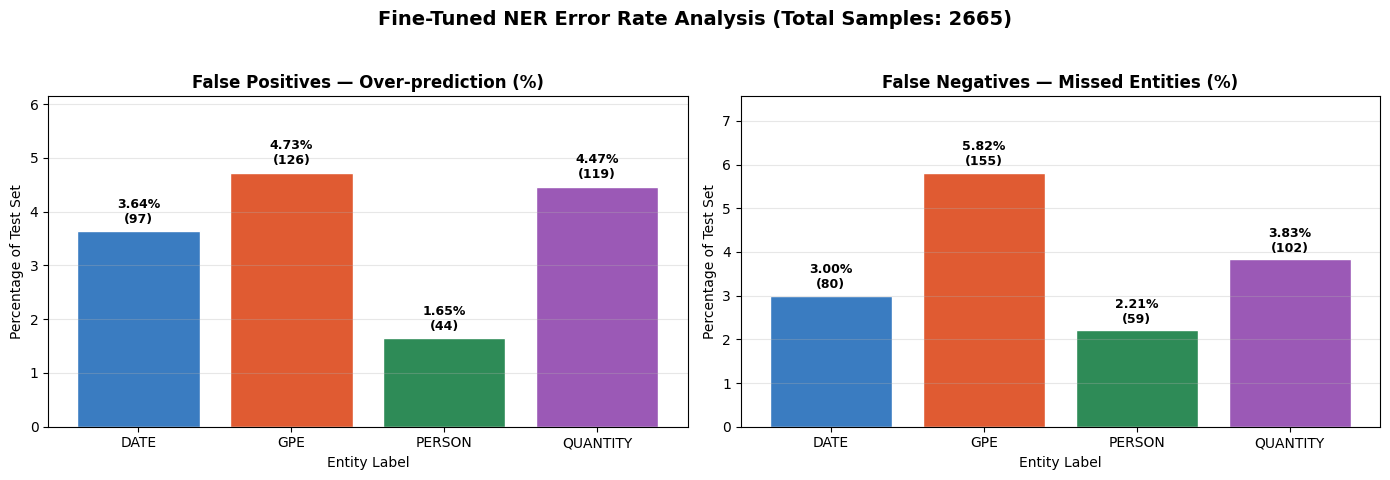

In [ ]:
# Visualise error percentages per label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

total_test_docs = len(all_test)

for ax, err_dict, title in [
    (axes[0], errors["fp"], "False Positives — Over-prediction (%)"),
    (axes[1], errors["fn"], "False Negatives — Missed Entities (%)"),
]:
    labels_ = sorted(TARGET_LABELS)
    # Calculate percentage of errors relative to total test set
    counts_ = [len(err_dict.get(l, [])) for l in labels_]
    pcts_   = [(c / total_test_docs) * 100 for c in counts_]

    colors_ = ["#3A7CC1", "#E05B32", "#2E8B57", "#9B59B6"][:len(labels_)]
    bars = ax.bar(labels_, pcts_, color=colors_, edgecolor="white")

    # Add both raw count and percentage labels on bars
    for bar, pct, count in zip(bars, pcts_, counts_):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f"{pct:.2f}%\n({count})", ha="center", va="bottom",
                fontsize=9, fontweight="bold")

    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Percentage of Test Set")
    ax.set_xlabel("Entity Label")
    ax.set_ylim(0, max(pcts_) * 1.3 if pcts_ else 10)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(f"Fine-Tuned NER Error Rate Analysis (Total Samples: {total_test_docs})", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("fig_ner_errors_pct.png", dpi=120, bbox_inches="tight")
plt.show()

---
## Section 12 — Qualitative Evaluation on BEMI Queries

Run both models on fresh BEMI-style queries not seen during training.
This is the most practical test — does the model work on the actual
input distribution the extractor will see at inference time?


In [ ]:
BEMI_EVAL_QUERIES = [
    # Geographic — Philippine cities (informal)
    "is it raining in cebu right now?",
    "what is the weather like in manila today",
    "how cold is baguio this morning?",
    "weather update for davao",
    "temperature in iloilo city",

    # Date — relative expressions
    "how many days until new year's eve?",
    "what day of the week is december 25?",
    "how long until the end of the month",
    "schedule something for next friday please",
    "how many days between now and june 30",

    # Quantity — units and amounts
    "convert 500 grams to ounces for me",
    "what is 100 dollars in pesos?",
    "how many kilometers is 26 miles",
    "convert 37 degrees celsius to fahrenheit",
    "how many liters is 2 gallons",

    # Mixed
    "will it be hot in cebu city tomorrow?",
    "convert 75 kilograms to pounds please",
    "what time is it in manila right now?",
]

def compare_predictions(query: str, base_nlp, ft_nlp) -> None:
    base_ents = [(e.text, e.label_) for e in base_nlp(query).ents
                 if e.label_ in TARGET_LABELS]
    ft_ents   = [(e.text, e.label_) for e in ft_nlp(query).ents
                 if e.label_ in TARGET_LABELS]
    match = "✓" if base_ents == ft_ents else "≠"
    print(f"  Query : {query}")
    print(f"  Base  : {base_ents}")
    print(f"  FT    : {ft_ents}  {match}")
    print()

print("Qualitative comparison — base vs fine-tuned on BEMI queries")
print("=" * 70)
for q in BEMI_EVAL_QUERIES:
    compare_predictions(q, nlp_base, nlp_best)


Qualitative comparison — base vs fine-tuned on BEMI queries
  Query : is it raining in cebu right now?
  Base  : []
  FT    : [('cebu', 'GPE'), ('right now', 'DATE')]  ≠

  Query : what is the weather like in manila today
  Base  : [('manila', 'GPE'), ('today', 'DATE')]
  FT    : [('manila', 'GPE'), ('today', 'DATE')]  ✓

  Query : how cold is baguio this morning?
  Base  : []
  FT    : [('this morning', 'DATE')]  ≠

  Query : weather update for davao
  Base  : []
  FT    : []  ✓

  Query : temperature in iloilo city
  Base  : []
  FT    : [('iloilo city', 'GPE')]  ≠

  Query : how many days until new year's eve?
  Base  : [("new year's eve", 'DATE')]
  FT    : [('new year', 'DATE')]  ≠

  Query : what day of the week is december 25?
  Base  : [('what day of the week', 'DATE'), ('december 25', 'DATE')]
  FT    : [('december 25', 'DATE')]  ≠

  Query : how long until the end of the month
  Base  : [('the end of the month', 'DATE')]
  FT    : []  ≠

  Query : schedule something for next 

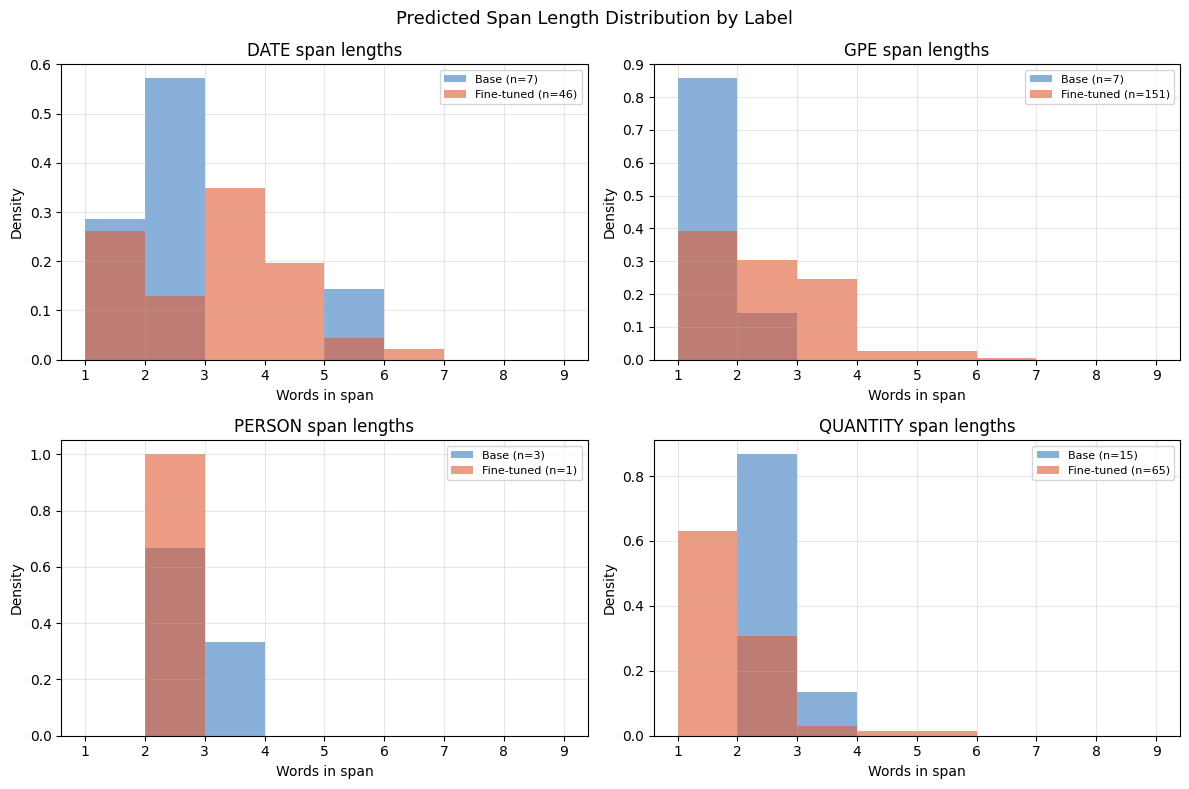

In [ ]:
# What span lengths does each model tend to produce?
def get_pred_span_lengths(nlp_model, test_samples):
    lengths_by_label = defaultdict(list)
    for text, _ in test_samples:
        for ent in nlp_model(text).ents:
            if ent.label_ in TARGET_LABELS:
                lengths_by_label[ent.label_].append(len(ent.text.split()))
    return lengths_by_label

base_lengths = get_pred_span_lengths(nlp_base, all_test[:200])
ft_lengths   = get_pred_span_lengths(nlp_best, all_test[:200])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, label in zip(axes.flat, sorted(TARGET_LABELS)):
    bl = base_lengths.get(label, [1])
    fl = ft_lengths.get(label, [1])
    ax.hist(bl, bins=range(1, 10), alpha=0.6,
            color="#3A7CC1", label=f"Base (n={len(bl)})", density=True)
    ax.hist(fl, bins=range(1, 10), alpha=0.6,
            color="#E05B32", label=f"Fine-tuned (n={len(fl)})", density=True)
    ax.set_title(f"{label} span lengths")
    ax.set_xlabel("Words in span"); ax.set_ylabel("Density")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Predicted Span Length Distribution by Label", fontsize=13)
plt.tight_layout()
plt.savefig("fig_span_lengths.png", dpi=120, bbox_inches="tight")
plt.show()


---
## Section 13 — Save & Integration Instructions

In [ ]:
import os
os.makedirs("./models", exist_ok=True)

# Save final fine-tuned model (already saved during training as best checkpoint)
# Confirm it's there:
if Path("./models/bemi-ner-best").exists():
    print("Fine-tuned model already saved at: ./models/bemi-ner-best/")
else:
    nlp_best.to_disk("./models/bemi-ner-best")
    print("Saved: ./models/bemi-ner-best/")

# Save final metrics to JSON for the evaluation report
final_metrics = {
    "base_model": {
        "precision": round(baseline_final["precision"], 4),
        "recall":    round(baseline_final["recall"], 4),
        "f1":        round(baseline_final["f1"], 4),
        "per_type":  {k: {m: round(v,4) for m,v in s.items()}
                      for k,s in baseline_final["per_type"].items()},
    },
    "fine_tuned": {
        "precision": round(finetuned_final["precision"], 4),
        "recall":    round(finetuned_final["recall"], 4),
        "f1":        round(finetuned_final["f1"], 4),
        "per_type":  {k: {m: round(v,4) for m,v in s.items()}
                      for k,s in finetuned_final["per_type"].items()},
    },
    "best_epoch":      best_epoch,
    "training_history": history,
    "n_train_samples": len(train_examples),
    "n_test_samples":  len(all_test),
}

with open("./models/ner_evaluation.json", "w") as f:
	def make_serializable(obj):
		if isinstance(obj, dict):
			return {k: make_serializable(v) for k, v in obj.items()}
		if isinstance(obj, list):
			return [make_serializable(v) for v in obj]
		if isinstance(obj, tuple) or isinstance(obj, set):
			return [make_serializable(v) for v in obj]
		if isinstance(obj, np.ndarray):
			return obj.tolist()
		if isinstance(obj, np.generic):
			return obj.item()
		if isinstance(obj, defaultdict):
			return {k: make_serializable(v) for k, v in obj.items()}
		return obj

	json.dump(make_serializable(final_metrics), f, indent=2)
print("Saved: ./models/ner_evaluation.json")


Fine-tuned model already saved at: ./models/bemi-ner-best/
Saved: ./models/ner_evaluation.json


### Final Model Export
Since the evaluation showed the model with default hyperparameters performed slightly better, we will designate it as the final production model.

In [ ]:
import shutil
from pathlib import Path

# Source: best performing model based on F1 comparison
source_path = "./models/bemi-ner-best"
dest_path = "./models/bemi-ner-final"

if Path(source_path).exists():
    if Path(dest_path).exists():
        shutil.rmtree(dest_path)
    shutil.copytree(source_path, dest_path)
    print(f"✓ Final production model exported to: {dest_path}")
else:
    print("⚠ Best model path not found. Please ensure the training cells ran successfully.")

✓ Final production model exported to: ./models/bemi-ner-final


### Joblib Model Export
Exporting the fine-tuned spaCy model object using `joblib` serialization.

In [ ]:
import joblib
from pathlib import Path

# Ensure the model is loaded in the current session
if 'nlp_best' not in locals():
    import spacy
    nlp_best = spacy.load("./models/bemi-ner-best")

# Define export path
joblib_path = "./models/bemi-ner-model.joblib"

# Export the entire NLP object
joblib.dump(nlp_best, joblib_path)

print(f"✓ Model successfully exported using joblib to: {joblib_path}")
print(f"File size: {Path(joblib_path).stat().st_size / 1024**2:.2f} MB")

✓ Model successfully exported using joblib to: ./models/bemi-ner-model.joblib
File size: 15.59 MB


### Using the Fine-Tuned spaCy Model with Ollama

Your fine-tuned spaCy model has been saved to disk at `./models/bemi-ner-final` and as a `joblib` file at `./models/bemi-ner-model.joblib`.

Directly inferring a spaCy model (whether saved with `to_disk` or `joblib`) with Ollama is not straightforward, as Ollama primarily works with models in formats like GGUF, which are typically used for large language models (LLMs) or other compatible architectures. spaCy models are distinct and optimized for NLP tasks within a Python environment.

**To use this model, you would typically:**

1.  **Load it in a Python environment:**

    ```python
    import spacy
    import joblib

    # Load using spaCy's native method
    nlp_loaded_spacy = spacy.load("./models/bemi-ner-final")

    # Or load using joblib
    nlp_loaded_joblib = joblib.load("./models/bemi-ner-model.joblib")

    # Example usage
    doc = nlp_loaded_spacy("What is the weather in Cebu tomorrow?")
    for ent in doc.ents:
        print(ent.text, ent.label_)
    ```

2.  **For Ollama integration:**

    *   **Custom API/Service:** The most common approach is to create a small Python API (e.g., using Flask or FastAPI) that loads your spaCy model and exposes an endpoint for NER predictions. Ollama (or any other service) could then call this API.

    *   **Model Conversion (Complex):** If you intend to run a spaCy model directly within Ollama's ecosystem, it would likely require a complex conversion process, potentially involving re-implementing the spaCy NER architecture (a transition-based system with a CNN component) in a format (like GGUF) that Ollama supports. This is generally not feasible or recommended without significant effort and expertise in model serialization for different inference engines.

**Recommendation:** For practical use, it's best to deploy your spaCy model within a dedicated Python-based service or application, and then integrate that service with your Ollama setup if needed.

---
Limitations

1. **BEMI hand-annotations are small (≈40 examples).** They anchor the model
   to Philippine geography and skill vocabulary but are too few to drive
   significant weight updates on their own. Their value is in preventing
   catastrophic forgetting on domain-specific terms during the SNIPS/MIT training.

2. **MIT Restaurant and MIT Movie are US-centric.** City names and date expressions
   in these datasets reflect English-US conventions. Philippine city names
   (Lapu-Lapu, Cagayan de Oro, General Santos) are entirely absent. The BEMI
   hand-annotations partially compensate for this.

3. **Span boundaries are approximate.** The `alignment_mode="expand"` setting
   in `char_span()` snaps boundaries to the nearest token edge, which can
   slightly over-extend short spans. This is a known trade-off in BIO→spaCy conversion.

4. **Entity ambiguity.** "May" is a month (DATE) and a name (PERSON). "General Santos"
   contains a rank (modifier) before a GPE. The NER model sees these in context but
   may still be confused by unusual constructions.

5. **No dialect or code-switching coverage.** Filipino users often mix Tagalog and
   English ("anong weather sa Cebu?"). The model will not extract entities from
   non-English portions of mixed queries. Handling this would require a multilingual
   base model (e.g. `xx_ent_wiki_sm`) rather than `en_core_web_sm`.
